In [3]:
from ultralytics import YOLO

import torch
import matplotlib.pyplot as plt
import numpy as np 
import cv2

## Area detection

In [4]:
# Load area_detection_model
area_detection_model = YOLO("../../training/object_detection/runs/detect/train/weights/best.pt")

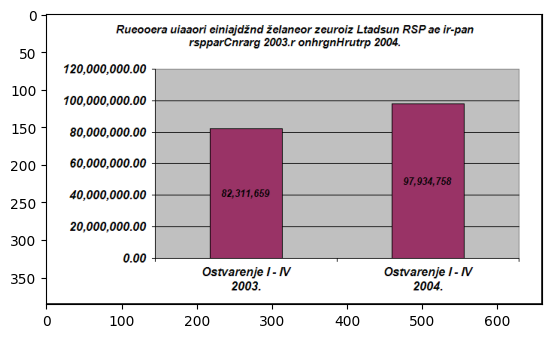

In [5]:
img_path = "../../assets/dataset/reduced_data/bardata(1031)/bar/images/train2019/013643546a25fd94fa9345a763b83304_d3d3Lmdvdi5tZQkxOTUuNjYuMTY2Ljgx.xls-0-0.png"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)

In [6]:
area_detect_results = area_detection_model(img_path)[0]


image 1/1 d:\Projects\ChartInsight\testing\barchart\..\..\assets\dataset\reduced_data\bardata(1031)\bar\images\train2019\013643546a25fd94fa9345a763b83304_d3d3Lmdvdi5tZQkxOTUuNjYuMTY2Ljgx.xls-0-0.png: 384x640 1 ChartTitle, 1 PlotArea, 1 InnerPlotArea, 62.1ms
Speed: 2.1ms preprocess, 62.1ms inference, 57.1ms postprocess per image at shape (1, 3, 384, 640)


In [7]:
area_anns = area_detect_results.boxes.data
area_anns

tensor([[145.6056,  74.2527, 628.9503, 324.6234,   0.9775,   5.0000],
        [ 20.7592,  62.0197, 630.7706, 373.9297,   0.9626,   4.0000],
        [ 84.7154,  12.6216, 577.6978,  50.1352,   0.8409,   2.0000]], device='cuda:0')

In [8]:
plot_area_anns = area_anns[area_anns[:, 5] == 4].cpu().numpy()
plot_area_anns

array([[     20.759,       62.02,      630.77,      373.93,     0.96265,           4]], dtype=float32)

In [9]:
plot_area_anns = plot_area_anns[0]
plot_area_anns

array([     20.759,       62.02,      630.77,      373.93,     0.96265,           4], dtype=float32)

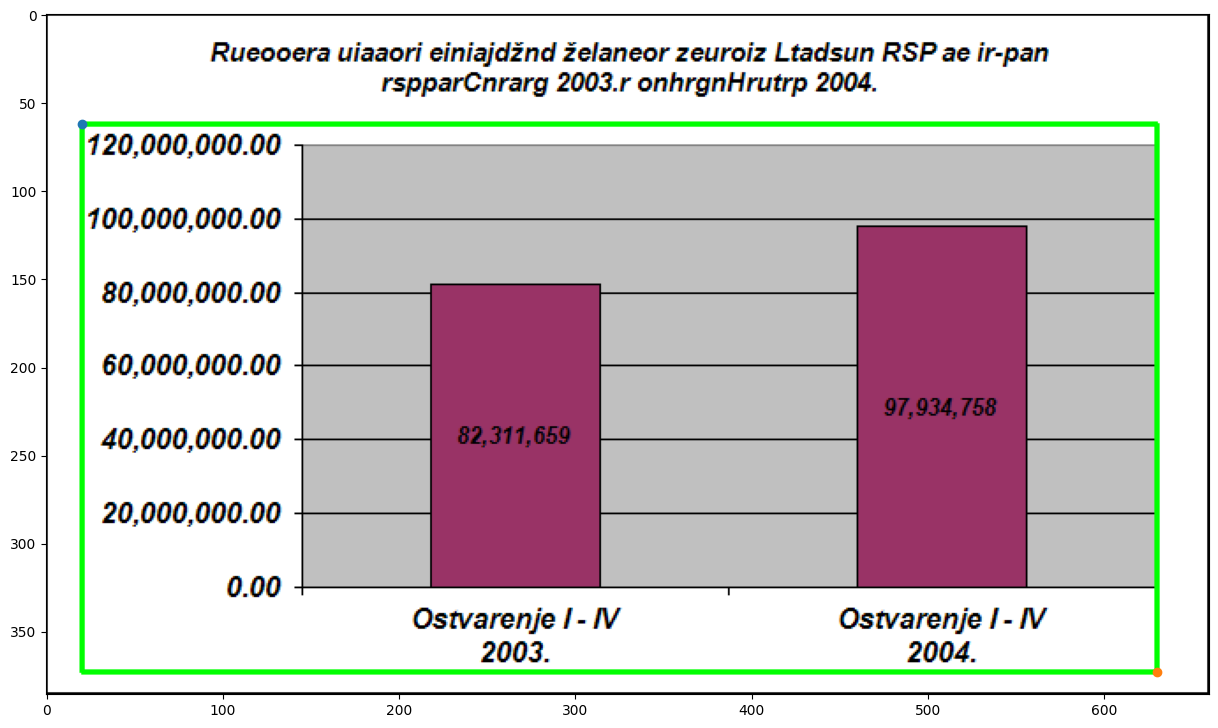

In [10]:
plt.figure(figsize=(15, 10))

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_copy = img.copy()

x1, y1, x2, y2, conf, cls = map(int, plot_area_anns[:6])
cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
plt.scatter(x1, y1)
plt.scatter(x2, y2)

plt.imshow(img_copy)

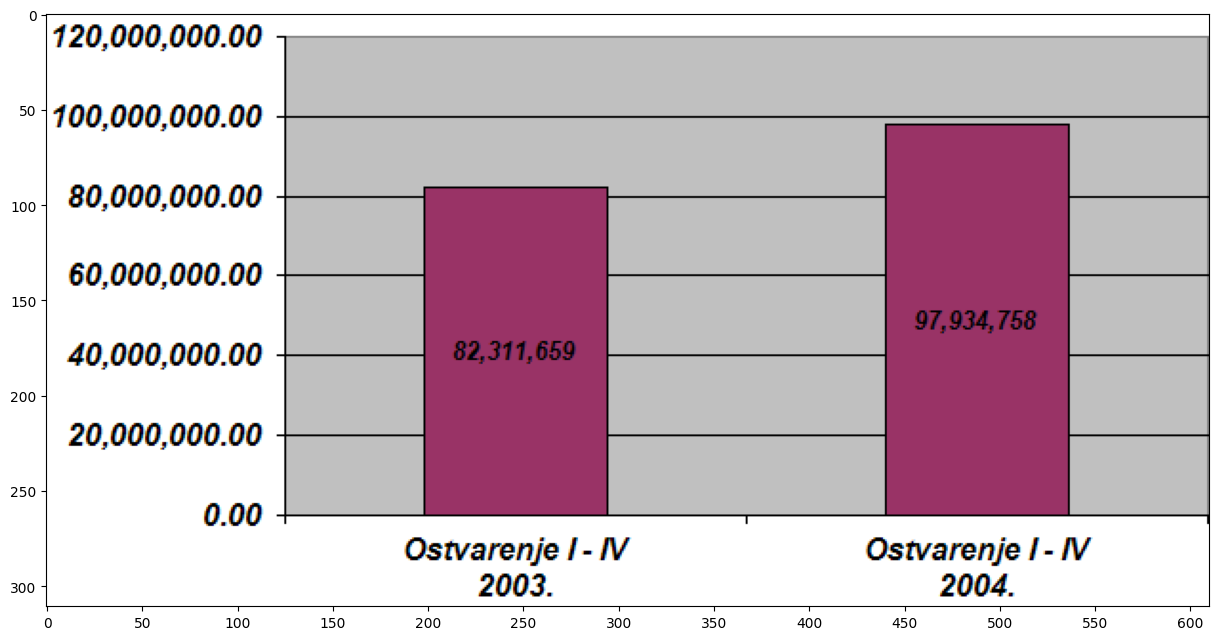

In [11]:
plt.figure(figsize=(15, 10))

x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
cropped_img = img[y1:y2, x1:x2]

x_ticks = np.arange(0, img.shape[1], step=50) 
plt.xticks(x_ticks)  
plt.imshow(cropped_img)

## Bar detection

In [12]:
bar_detection = YOLO('./runs/detect/train/weights/best.pt')

In [13]:
bar_detect_results = bar_detection(cropped_img)[0]


0: 352x640 2 Seriess, 59.2ms
Speed: 1.5ms preprocess, 59.2ms inference, 1.8ms postprocess per image at shape (1, 3, 352, 640)


In [14]:
bar_anns = bar_detect_results.boxes.data.cpu().numpy()
bar_anns

array([[     441.95,      57.163,      536.12,      259.67,     0.97729,           0],
       [     199.39,      87.938,      294.06,      263.08,     0.95832,           0]], dtype=float32)

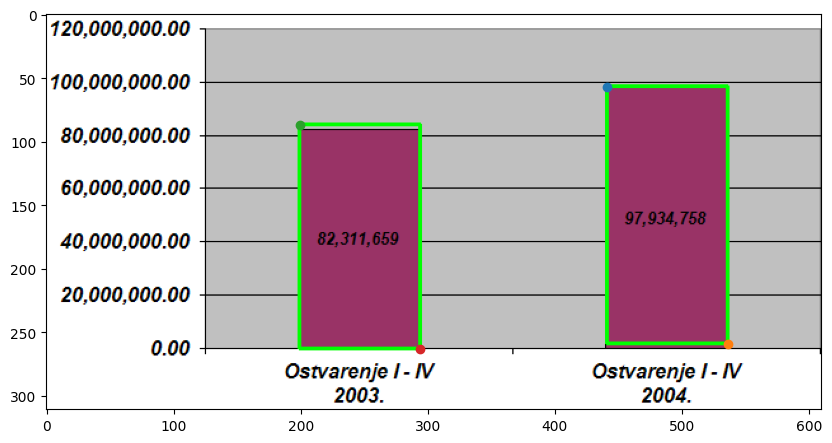

In [15]:
cropped_copy = cropped_img.copy()

plt.figure(figsize=(10, 8))
for bbox in bar_anns:
    x1, y1, x2, y2, conf, cls = map(int, bbox)
    cv2.rectangle(cropped_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
    plt.scatter(x1, y1)
    plt.scatter(x2, y2)
    
plt.imshow(cropped_copy)

## OCR detection

In [16]:
from paddleocr import PaddleOCR

In [17]:
ocr = PaddleOCR(use_angle_cls=True, lang='en')

[2025/03/03 10:45:05] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\admin/.paddleocr/whl\\det\\en\\en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\admin/.paddleocr/whl\\rec\\en\\en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=

In [18]:
ocr_results = ocr.ocr(cropped_img, cls=True)
for idx in range(len(ocr_results)):
    ocr_res = ocr_results[idx]
    for line in ocr_res:
        print(line)

[2025/03/03 10:45:07] ppocr DEBUG: dt_boxes num : 13, elapsed : 0.24681973457336426
[2025/03/03 10:45:07] ppocr DEBUG: cls num  : 13, elapsed : 0.06408500671386719
[2025/03/03 10:45:08] ppocr DEBUG: rec_res num  : 13, elapsed : 1.1057679653167725
[[[3.0, 4.0], [114.0, 4.0], [114.0, 20.0], [3.0, 20.0]], ('120,000,000.00', 0.9987020492553711)]
[[[3.0, 46.0], [114.0, 46.0], [114.0, 62.0], [3.0, 62.0]], ('100,000,000.00', 0.9981475472450256)]
[[[12.0, 89.0], [113.0, 89.0], [113.0, 103.0], [12.0, 103.0]], ('80,000,000.00', 0.9913462996482849)]
[[[11.0, 128.0], [114.0, 128.0], [114.0, 145.0], [11.0, 145.0]], ('60,000,000.00', 0.9966716170310974)]
[[[453.0, 154.0], [521.0, 154.0], [521.0, 167.0], [453.0, 167.0]], ('97,934,758', 0.9940093159675598)]
[[[12.0, 172.0], [113.0, 172.0], [113.0, 186.0], [12.0, 186.0]], ('40,000,000.00', 0.9950435161590576)]
[[[213.0, 170.0], [279.0, 170.0], [279.0, 184.0], [213.0, 184.0]], ('82,311, 659', 0.9644161462783813)]
[[[11.0, 213.0], [114.0, 213.0], [114.0,

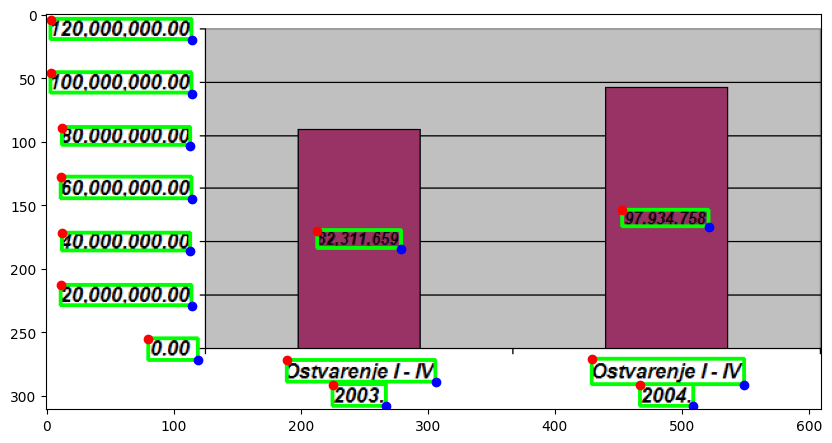

In [19]:
cropped_copy = cropped_img.copy()

plt.figure(figsize=(10, 8))

for bbox in ocr_res:
    points = np.array(bbox[0], dtype=np.int32) 

    x1, y1 = points[0]  
    x2, y2 = points[2]  

    cv2.rectangle(cropped_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.scatter(x1, y1, color='red')
    plt.scatter(x2, y2, color='blue')

plt.imshow(cropped_copy)
plt.show()

In [20]:
import re

In [21]:
def is_numeric(text):
    cleaned_text = re.sub(r'[^\d\.]', '', text) 
    try:
        float(cleaned_text)
        return True
    except ValueError:
        return False

def filter_y_axis_labels(ocr_results, x_threshold=120):
    """
    Lọc các kết quả OCR mà trung điểm của bbox nằm bên trái x_threshold.
    """
    y_axis_labels = []
    for res in ocr_results:
        bbox, (text, conf) = res
        # Tính trung điểm x của bbox
        x_coords = [pt[0] for pt in bbox]
        x_mean = sum(x_coords) / len(x_coords)
        if x_mean < x_threshold and is_numeric(text):
            # Lấy trung điểm y (dùng để sắp xếp)
            y_coords = [pt[1] for pt in bbox]
            y_mean = sum(y_coords) / len(y_coords)
            y_axis_labels.append({'text': text, 'conf': conf, 'x_mean': x_mean, 'y_mean': y_mean})
    return y_axis_labels

y_labels = filter_y_axis_labels(ocr_res)
y_labels

[{'text': '120,000,000.00',
  'conf': 0.9987020492553711,
  'x_mean': 58.5,
  'y_mean': 12.0},
 {'text': '100,000,000.00',
  'conf': 0.9981475472450256,
  'x_mean': 58.5,
  'y_mean': 54.0},
 {'text': '80,000,000.00',
  'conf': 0.9913462996482849,
  'x_mean': 62.5,
  'y_mean': 96.0},
 {'text': '60,000,000.00',
  'conf': 0.9966716170310974,
  'x_mean': 62.5,
  'y_mean': 136.5},
 {'text': '40,000,000.00',
  'conf': 0.9950435161590576,
  'x_mean': 62.5,
  'y_mean': 179.0},
 {'text': '20,000,000.00',
  'conf': 0.9969272017478943,
  'x_mean': 62.5,
  'y_mean': 221.0},
 {'text': '0.00', 'conf': 0.9997192025184631, 'x_mean': 99.5, 'y_mean': 263.5}]

In [22]:
def parse_number(text):
    return float(re.sub(r'[^\d\.]', '', text) )

# Sắp xếp theo y_mean (giá trị nhỏ nhất ở trên cùng)
y_labels_sorted = sorted(y_labels, key=lambda x: x['y_mean'])
if len(y_labels_sorted) >= 2:
    max_label = y_labels_sorted[0]  # trên cùng, giá trị lớn nhất
    min_label = y_labels_sorted[-1] # dưới cùng, giá trị nhỏ nhất

    max_value = parse_number(max_label['text'])
    min_value = parse_number(min_label['text'])
    print("Max value:", max_value, "Min value:", min_value)
else:
    print("Không đủ thông tin nhãn trục Y để xác định dải giá trị.")

Max value: 120000000.0 Min value: 0.0


In [23]:
delta_y = min_label['y_mean'] - max_label['y_mean']
if delta_y != 0:
    Yscale = (max_value - min_value) / delta_y
    print("Yscale (value per pixel):", Yscale)
else:
    print("Lỗi: delta_y = 0")

Yscale (value per pixel): 477137.17693836975


In [24]:
def get_bar_value(bar_bbox, plot_bottom, Yscale, max_value):
    # Lấy tọa độ y của cạnh trên của cột
    y_bar = bar_bbox[1]  # y_max
    # Tính khoảng cách từ cạnh dưới plot đến cạnh trên cột
    pixel_distance = plot_bottom - y_bar
    # Tính giá trị tương ứng: giá trị = giá trị tối đa - khoảng cách chuyển đổi
    bar_value = pixel_distance * Yscale
    return bar_value

# Ví dụ nếu bạn có danh sách các bar bounding boxes
bars = bar_anns
# Giả sử plot_bottom lấy từ min_label['y_mean'] hoặc có thể xác định từ vùng plot đã được crop
plot_bottom = min_label['y_mean']

for i, bar_bbox in enumerate(bars):
    value = get_bar_value(bar_bbox, plot_bottom, Yscale, max_value)
    print(f"Bar {i+1}: value = {value}")

Bar 1: value = 98451260.2121645
Bar 2: value = 83767184.49071197


In [25]:
def filter_x_axis_labels(ocr_results, y_threshold):
    """
    Lọc các kết quả OCR mà trung điểm y của bbox nằm dưới y_threshold
    và nội dung không phải là số (dùng làm nhãn).
    """
    x_axis_labels = []
    for res in ocr_results:
        bbox, (text, conf) = res
        # Tính trung điểm y của bbox
        y_coords = [pt[1] for pt in bbox]
        y_mean = sum(y_coords) / len(y_coords)
        # Tính trung điểm x của bbox để sắp xếp sau này
        x_coords = [pt[0] for pt in bbox]
        x_mean = sum(x_coords) / len(x_coords)
        
        # Nếu trung điểm y dưới ngưỡng và text không phải là số, coi là nhãn x-axis
        if y_mean > y_threshold and not is_numeric(text):
            x_axis_labels.append({'text': text, 'conf': conf, 'x_mean': x_mean, 'y_mean': y_mean})
    return x_axis_labels

In [26]:
# Giả sử plot_bottom là trung điểm y của nhãn trục Y dưới cùng (min_label)
# Nếu bạn chưa có, có thể dùng một giá trị cố định hoặc tính toán từ vùng plot.
plot_bottom = min_label['y_mean']  # từ bước trước

# Đặt ngưỡng y_threshold, ví dụ cộng thêm 20 pixel vào plot_bottom
y_threshold = plot_bottom   # từ bước trước

# Lọc các OCR text nằm dưới y_threshold
x_labels = filter_x_axis_labels(ocr_res, y_threshold)

# Sắp xếp nhãn theo thứ tự x tăng dần để khớp với thứ tự các cột từ trái sang phải
x_labels_sorted = sorted(x_labels, key=lambda item: item['x_mean'])

for label in x_labels_sorted:
    print("Label:", label['text'], "x_mean:", label['x_mean'], "y_mean:", label['y_mean'])

Label: Ostvarenje I - IV x_mean: 247.5 y_mean: 280.5
Label: Ostvarenje I- IV x_mean: 489.0 y_mean: 281.0


In [27]:
def assign_labels_to_bars(bars, x_labels_sorted):
    """
    bars: danh sách các bounding box của cột, mỗi bbox là [x_min, y_min, x_max, y_max]
    x_labels_sorted: danh sách nhãn x-axis đã sắp xếp theo x_mean.
    Trả về danh sách các tuple (bar_bbox, label_text)
    """
    assigned = []
    for bar in bars:
        # Tính trung điểm x của bar
        bar_center_x = (bar[0] + bar[2]) / 2.0
        # Tìm nhãn có x_mean gần nhất với bar_center_x
        closest_label = min(x_labels_sorted, key=lambda lbl: abs(lbl['x_mean'] - bar_center_x))
        assigned.append((bar, closest_label['text']))
    return assigned

# Giả sử bars là danh sách các bounding box của cột (đã có từ bước trước)
bar = bar_anns

assigned_labels = assign_labels_to_bars(bars, x_labels_sorted)
assigned_labels

[(array([     441.95,      57.163,      536.12,      259.67,     0.97729,           0], dtype=float32),
  'Ostvarenje I- IV'),
 (array([     199.39,      87.938,      294.06,      263.08,     0.95832,           0], dtype=float32),
  'Ostvarenje I - IV')]

In [28]:
def get_bars_with_labels_and_values(bars, x_labels_sorted, plot_bottom, Yscale, max_value):
    """
    Gán nhãn và tính toán giá trị cho các cột dựa trên vị trí và thang đo Y.

    Args:
        bars (list): Danh sách bbox của các cột [(x1, y1, x2, y2, conf, cls)].
        x_labels_sorted (list): Danh sách nhãn X được sắp xếp theo vị trí X trung bình.
        plot_bottom (float): Tọa độ Y của đáy biểu đồ.
        Yscale (float): Tỷ lệ trục Y (giá trị trên mỗi pixel).
        max_value (float): Giá trị lớn nhất trên trục Y.

    Returns:
        List[dict]: Danh sách các cột với thông tin bbox, tên, và giá trị.
    """
    bars_info = []
    
    for bar in bars:
        bar_center_x = (bar[0] + bar[2]) / 2.0  # Tính trung tâm X của cột
        closest_label = min(x_labels_sorted, key=lambda lbl: abs(lbl['x_mean'] - bar_center_x))  # Tìm nhãn gần nhất
        y_bar = bar[1]  # Điểm Y cao nhất của cột
        bar_value = (plot_bottom - y_bar) * Yscale  # Tính toán giá trị
        
        bars_info.append({
            'bbox': bar[:4],  # Chỉ lấy bbox (bỏ confidence & class)
            'label': closest_label['text'],
            'value': bar_value
        })
    
    return bars_info

In [29]:
bars_with_values = get_bars_with_labels_and_values(bars, x_labels_sorted, plot_bottom, Yscale, max_value)

for bar in bars_with_values:
    print(f"Cột '{bar['label']}' có giá trị: {bar['value']}")


Cột 'Ostvarenje I- IV' có giá trị: 98451260.2121645
Cột 'Ostvarenje I - IV' có giá trị: 83767184.49071197
